<a href="https://colab.research.google.com/github/jane-kirina/python_for_ds_and_ml_tasks/blob/main/module_2/topic_2/HW_2_2_3_Poly_Pipelines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [1]:
from google.colab import drive
import numpy as np
import pandas as pd
import inspect
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (OneHotEncoder, StandardScaler,
                                   PolynomialFeatures)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import (LogisticRegression, LinearRegression, Ridge,
                                  Lasso, ElasticNet)
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             ConfusionMatrixDisplay, mean_squared_error,
                             mean_absolute_error, r2_score)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Area under ROC score on Train dataset: 0.88%


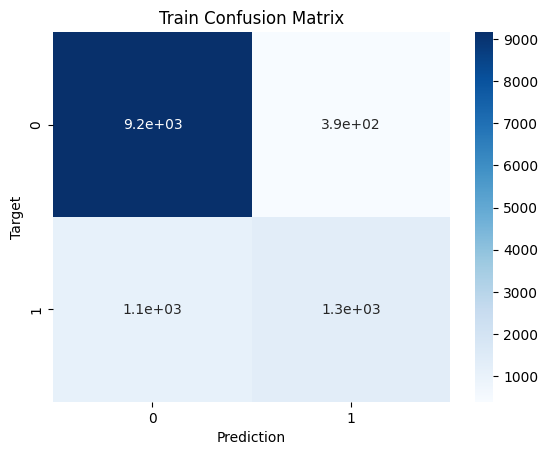

Area under ROC score on Validation dataset: 0.87%


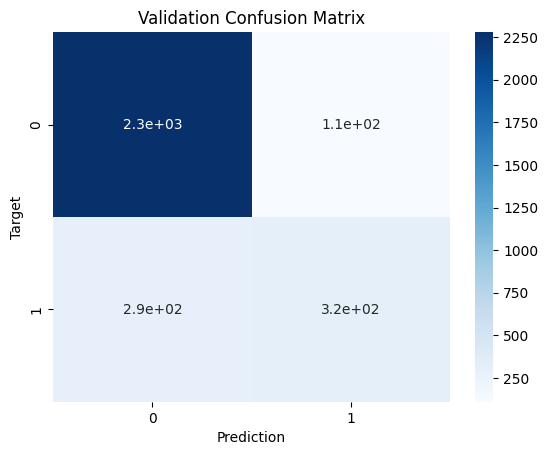

Saved


In [2]:
'''
1. Читання файлу з google drive
2. Розбиття на тренувальний і валідаційний набори,
де валідаційний містить 20% даних (поза пайплайном)
'''
drive.mount('/content/drive')
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/_DLA_/module_2/topic_2/kaggle_competition/data/"
raw_df = pd.read_csv(DATA_PATH + 'train.csv', index_col=0)
target_col = 'Exited'
train_df, val_df = train_test_split(raw_df, test_size=0.2,
                                    stratify=raw_df[target_col])

'''
3. Виділення категоріальних і числових колонок (поза пайплайном)
'''
drop_cols = ['id', 'CustomerId', 'Surname']
input_cols = [c for c in raw_df.columns if c not in drop_cols + [target_col]]

# target_col = ...

train_inputs = train_df[input_cols]
train_targets = train_df[target_col]

val_inputs = val_df[input_cols]
val_targets = val_df[target_col]

'''
4. Підготовку категоріальних і числових колонок (частина пайплайну)
В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок
в окремі трансформери numeric_transformer, categorical_cols
'''
# Виявляємо числові і категоріальні колонки
numeric_cols = train_inputs.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = train_inputs.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown="ignore")),
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

'''
5. Тренування лог регресії (частина пайплайну)
'''
# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000))
])
'''
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном)
'''
model_pipeline.fit(train_inputs, train_targets)

'''
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості
ROC-AUC + вивдення Confusion Matrix (поза пайплайном)
'''
# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)

    proba = model_pipeline.predict_proba(inputs)[:, 1]
    roc_auc = roc_auc_score(targets, proba)

    print(f'Area under ROC score on {name} dataset: {roc_auc:.2f}%')

    confusion_matrix_ = confusion_matrix(targets, preds)

    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_pred = predict_and_plot(model_pipeline, train_inputs, train_targets, name='Train')
val_pred = predict_and_plot(model_pipeline, val_inputs, val_targets, name='Validation')

'''
8. Збереження моделі в формат joblib (поза пайплайном)
'''
# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'log_reg_pipeline.joblib')
print('Saved')

**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train + poly dataset: 0.93%


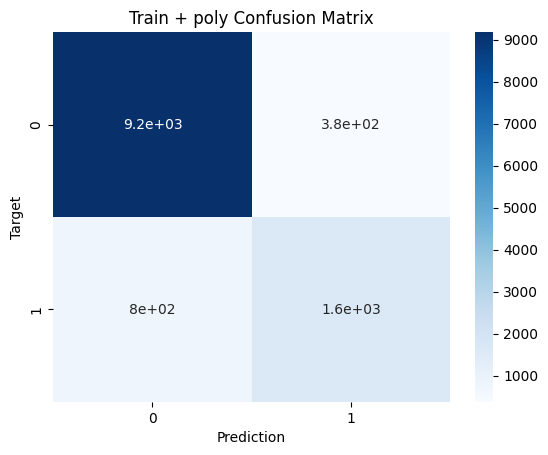

Area under ROC score on Validation + poly dataset: 0.93%


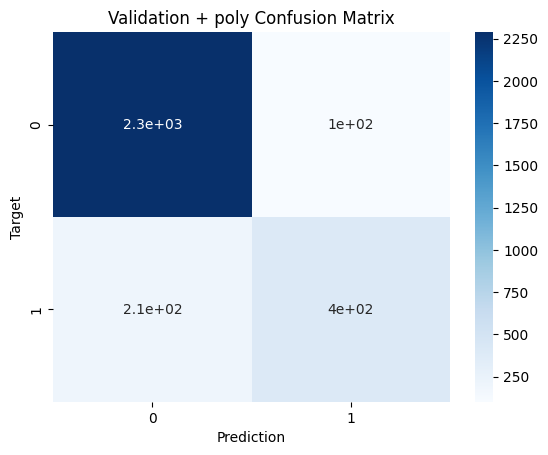

In [3]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_with_poly  = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_with_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_with_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# Новий пайплайн
model_pipeline_with_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_with_poly),
    ('classifier', LogisticRegression(max_iter=1000))
])

model_pipeline_with_poly.fit(train_inputs, train_targets)

# Metrics
train_pred_poly = predict_and_plot(model_pipeline_with_poly, train_inputs, train_targets, name='Train + poly')
val_pred_poly = predict_and_plot(model_pipeline_with_poly, val_inputs, val_targets, name='Validation + poly')

Модель без  polinomal features:
- Різниці майже нема, overfit не спостерігається, модель нормально генералізує, але є 'стеля' якості

Модель з  polinomal features:
- Якість зросла і при цьому розрив Train–Val маленький (`~0.01`),
overfit практично нема, модель добре генералізує


У порінянні:
- Polynomial features покращили модель: ROC-AUC виріс з `~0.88` до `~0.92`
- overfit не видно - ROC-AUC близьки
- Модель з poly краще узагальнює і дає кращу якість

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train + poly dataset: 0.94%


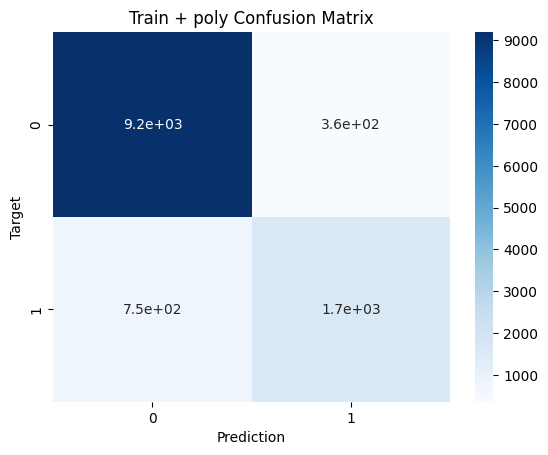

Area under ROC score on Validation + poly dataset: 0.93%


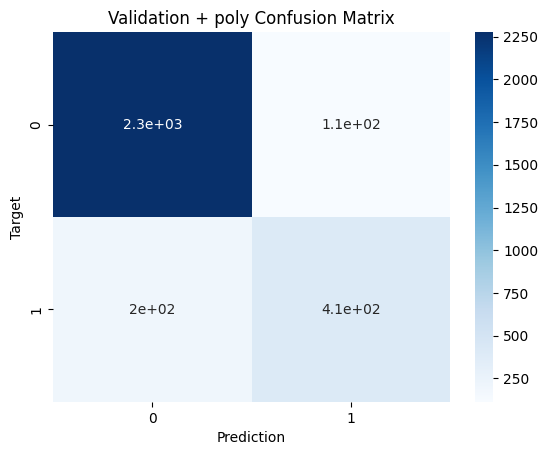

In [4]:
# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer_with_poly_4  = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=4, include_bias=False)),
    ('scaler', StandardScaler())
])

preprocessor_with_poly_4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_with_poly_4, numeric_cols),
        ('cat', categorical_transformer, categorical_cols),
    ]
)

# Новий пайплайн
model_pipeline_with_poly_4 = Pipeline(steps=[
    ('preprocessor', preprocessor_with_poly_4),
    ('classifier', LogisticRegression(max_iter=4000))
])

model_pipeline_with_poly_4.fit(train_inputs, train_targets)

# Metrics
train_pred_poly = predict_and_plot(model_pipeline_with_poly_4, train_inputs, train_targets, name='Train + poly')
val_pred_poly = predict_and_plot(model_pipeline_with_poly_4, val_inputs, val_targets, name='Validation + poly')

- ROC-AUC Train = 0.94
- ROC-AUC Validation = 0.92

У порівнянні:
- degree=2 (Train 0.93 / Val 0.92) — валідація не виросла та залишилась на `~0.92`, але train став трохи кращим
- різниця Train–Val = 0.02 → це легкий overfit

Генералізація все ще хороша, бо val високий, але degree=4 не дає переваги над degree=2

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [5]:
drive.mount('/content/drive')
DATA_PATH_REG_DATA = "/content/drive/MyDrive/Colab Notebooks/_DLA_/module_2/topic_2/data/"
raw_df = pd.read_csv(DATA_PATH_REG_DATA + 'regression_data.csv', index_col=0)

target_col = 'target'

X = raw_df.drop(columns=[target_col])
y = raw_df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

reg_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('poly', PolynomialFeatures(degree=5, include_bias=False)),
    ('scaler', StandardScaler()),
    ('model', LinearRegression())
])

reg_pipeline.fit(X_train, y_train)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('poly', PolynomialFeatures(degree=5, include_bias=False)),
                ('scaler', StandardScaler()), ('model', LinearRegression())])

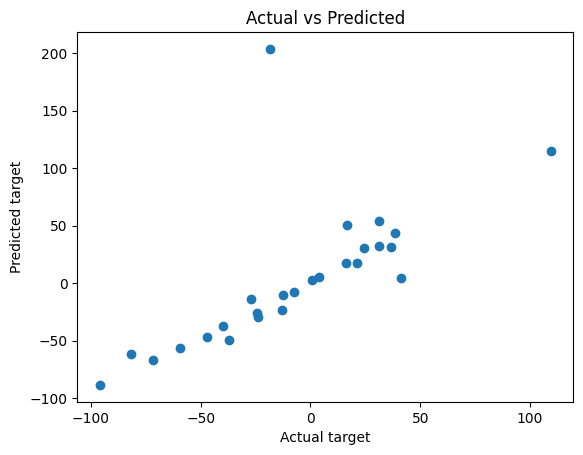

In [6]:
y_pred = reg_pipeline.predict(X_test)

plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel('Actual target')
plt.ylabel('Predicted target')
plt.title('Actual vs Predicted')
plt.show()

In [7]:
print('MAE:', mean_absolute_error(y_test, y_pred))
print('MSE:', mean_squared_error(y_test, y_pred))
print('R2 score:', r2_score(y_test, y_pred))

MAE: 16.45240462148043
MSE: 2057.068805489538
R2 score: -0.048092213370990455


- Модель дуже сильно промахується: R2 score = ~ -2.16
- Actual vs Predicted графік хаотичний
- В середньому модель помиляється на 26 одиниць target: MAE ~ 27

Модель лінійної регресії з PolynomialFeatures(degree=5) показує погані результати у тестовому наборі. Модель overfitting через високий поліноміальний ступінь


**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [8]:
# def draw_plot(y_true, y_pred, name):
  # # True vs Predicted
  # plt.figure()
  # plt.scatter(y_true, y_pred)
  # plt.xlabel('True y')
  # plt.ylabel('Predicted y')
  # plt.title(f'{name}: True vs Predicted')
  # plt.show()
#
  # # Residuals plot
  # residuals = np.asarray(y_true) - np.asarray(y_pred)
#
  # plt.figure()
  # plt.scatter(y_pred, residuals)
  # plt.axhline(0)
  # plt.xlabel('Predicted y')
  # plt.ylabel('Residuals (y - pred)')
  # plt.title(f'{name}: Residuals vs Predicted')
  # plt.show()

def cal_metrics(y_true, y_pred):
  rmse = np.sqrt(mean_squared_error(y_true, y_pred))
  mae  = mean_absolute_error(y_true, y_pred)
  r2   = r2_score(y_true, y_pred)
  return rmse, mae, r2

def make_regression_report(model, X_train, y_train, X_test, y_test, name='Reg',
                           is_draw_plot=True):
  pred_train = model.predict(X_train)
  pred_test = model.predict(X_test)

  rmse_train, mae_train, r2_train = cal_metrics(y_train, pred_train)
  rmse_test, mae_test, r2_test = cal_metrics(y_test,  pred_test)

  print(f'{name}')
  print(f'Train: RMSE={rmse_train:.4f} | MAE={mae_train:.4f} | R2={r2_train:.4f}')
  print(f'Test: RMSE={rmse_test:.4f} | MAE={mae_test:.4f} | R2={r2_test:.4f}')
  print('-'*50)

  #if is_draw_plot: # Графіків занадто багато для нашою задачі, бо в нас декілька моделей
  #  draw_plot(y_test, pred_test, name)

  return {'model': name,
          'rmse_train': rmse_train,
          'rmse_test': rmse_test,
          'mae_train': mae_train,
          'mae_test': mae_test,
          'r2_train': r2_train,
          'r2_test': r2_test}

In [9]:
def make_poly_reg_pipeline(regressor, degree=2):
    return Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('model', regressor)
    ])

pipelines = [
    ('LinearRegression', make_poly_reg_pipeline(
        LinearRegression(),
        20
        )),
    ('Ridge_20', make_poly_reg_pipeline(
        Ridge(alpha=1.0, random_state=42),
        20
        )),
    ('Lasso_20', make_poly_reg_pipeline(
        Lasso(alpha=0.001, max_iter=20000, random_state=42),
        20
        )),
    ('ElasticNet_20', make_poly_reg_pipeline(
        ElasticNet(alpha=0.001, l1_ratio=0.5, max_iter=20000, random_state=42),
        20
    ))
]

results = []

for name, pipe in pipelines:
    pipe.fit(X_train, y_train)
    results.append(make_regression_report(pipe, X_train, y_train, X_test, y_test, name=name))

results_df = pd.DataFrame(results).sort_values(by='rmse_test')

LinearRegression
Train: RMSE=0.0000 | MAE=0.0000 | R2=1.0000
Test: RMSE=30.5757 | MAE=11.6653 | R2=0.5237
--------------------------------------------------
Ridge_20
Train: RMSE=1.2830 | MAE=0.7458 | R2=0.9992
Test: RMSE=7.1723 | MAE=4.2065 | R2=0.9738
--------------------------------------------------
Lasso_20
Train: RMSE=0.5542 | MAE=0.3557 | R2=0.9999
Test: RMSE=2.6530 | MAE=1.8325 | R2=0.9964
--------------------------------------------------
ElasticNet_20
Train: RMSE=0.4066 | MAE=0.2437 | R2=0.9999
Test: RMSE=7.2613 | MAE=3.9538 | R2=0.9731
--------------------------------------------------


In [10]:
results_df

,model,rmse_train,rmse_test,mae_train,mae_test,r2_train,r2_test
2,Lasso_20,5.542478e-01,2.653041,3.556722e-01,1.832540,0.999852,0.996414
1,Ridge_20,1.283037e+00,7.172274,7.457738e-01,4.206549,0.999205,0.973790
3,ElasticNet_20,4.065622e-01,7.261257,2.436686e-01,3.953838,0.999920,0.973136
0,LinearRegression,5.551771e-13,30.575740,3.230544e-13,11.665314,1.000000,0.523674


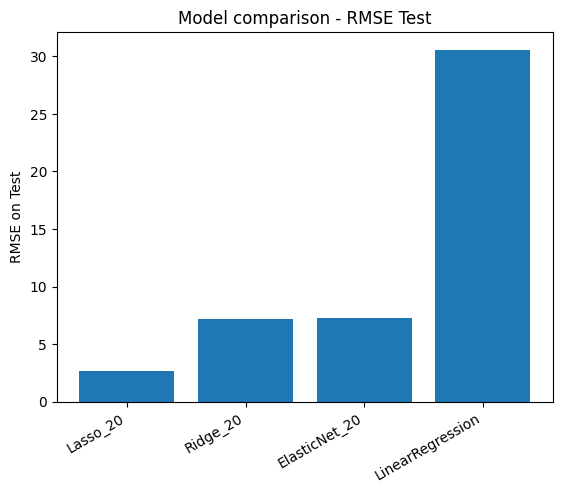

In [11]:
# Bar chart - RMSE Test
plt.figure()
plt.bar(results_df['model'], results_df['rmse_test'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('RMSE on Test')
plt.title('Model comparison - RMSE Test')
plt.show()

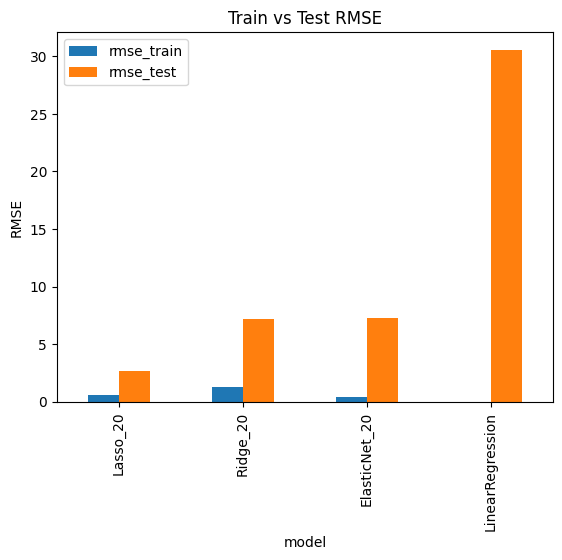

In [12]:
# Train vs Test RMSE
results_df.set_index('model')[['rmse_train', 'rmse_test']].plot(kind='bar')

plt.ylabel('RMSE')
plt.title('Train vs Test RMSE')
plt.show()

In [13]:
res_long = results_df.melt(
    id_vars='model',
    value_vars=['rmse_train', 'rmse_test'],
    var_name='dataset',
    value_name='rmse'
)

fig = px.bar(
    res_long,
    x='model',
    y='rmse',
    color='dataset',
    barmode='group',
    title='Train vs Test RMSE'
)
fig.show()

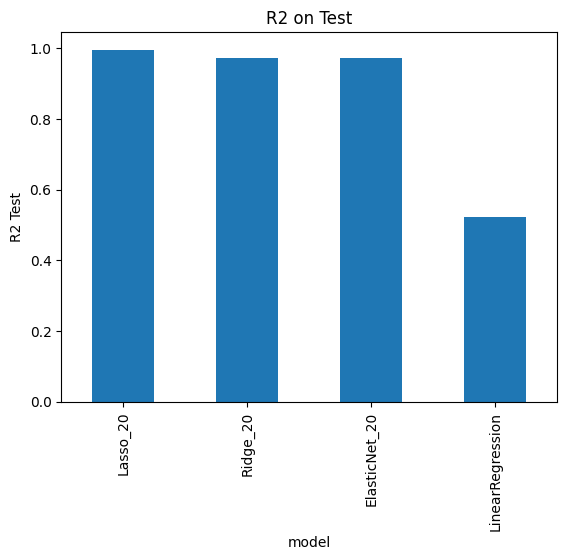

In [14]:
# R^2 Test
results_df.set_index('model')['r2_test'].plot(kind='bar')

plt.ylabel('R2 Test')
plt.title('R2 on Test')
plt.show()

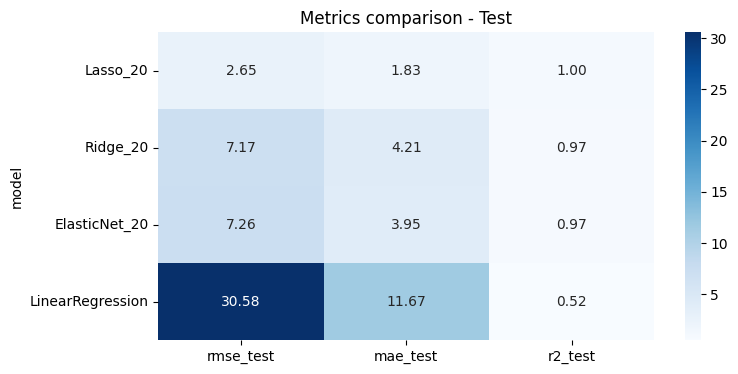

In [15]:
plt.figure(figsize=(8,4))
sns.heatmap(
    results_df.set_index('model')[['rmse_test', 'mae_test', 'r2_test']],
    annot=True,
    fmt='.2f',
    cmap='Blues'
)
plt.title('Metrics comparison - Test')
plt.show()

Найкраще генералізує Lasso (degree=20):
- На тесті  найменший RMSE/MAE і найвищий R² (~0.99), при цьому train і test метрики дуже близькі. Модель добре переноситься на нові дані та майже немає overfit

При degree=20 з’являється дуже багато поліноміальних фіч (і багато з них зайві/шумні/сильно скорельовані). Lasso (L1-регуляризація) зануляє частину коефіцієнтів, фактично робить відбір ознак та зменшує складніть модели, що допомагає проти overfit